## Model Evaluation

### Confusion Matrices — All Models

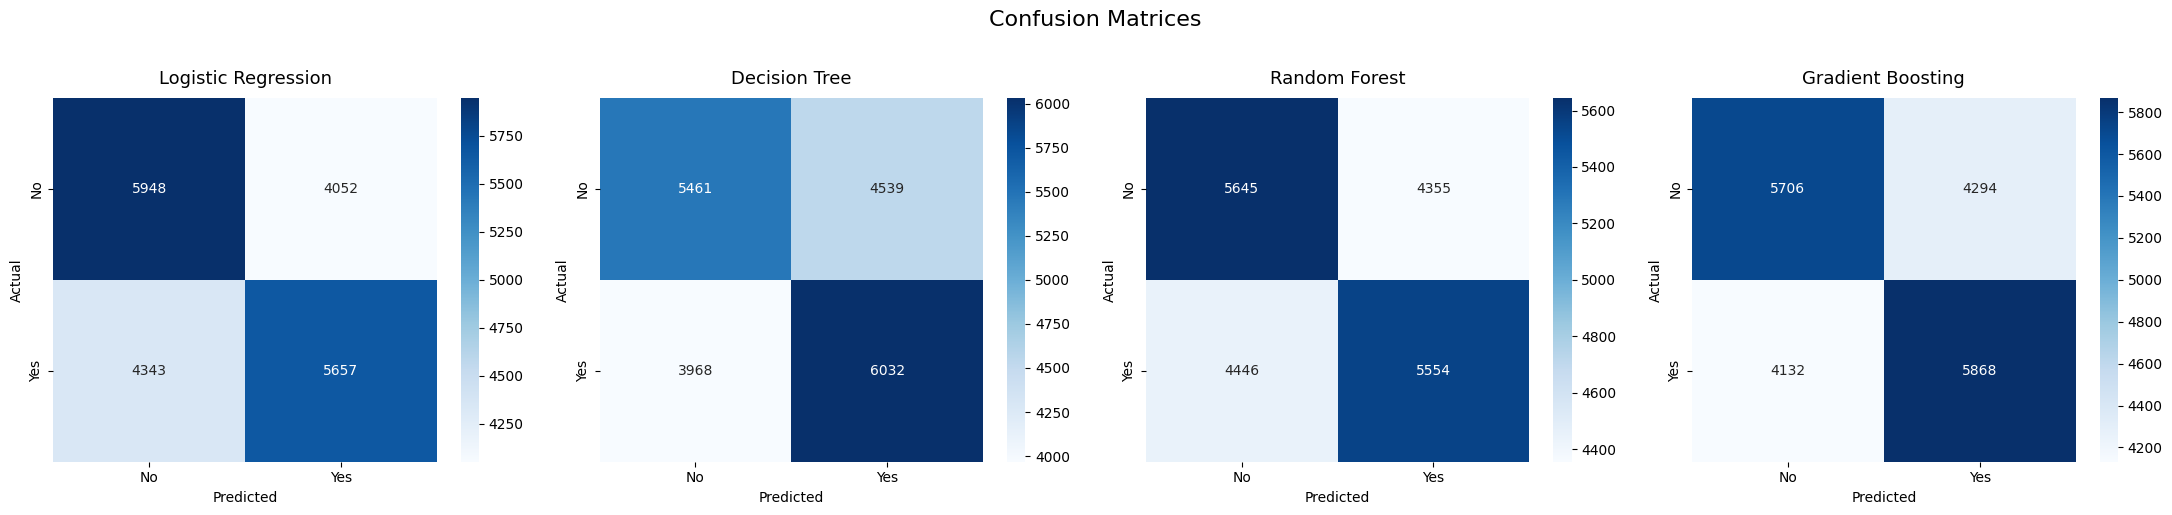

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

models_info = [
    ('Logistic Regression', lr_preds),
    ('Decision Tree',       dt_preds),
    ('Random Forest',       rf_preds),
    ('Gradient Boosting',   gb_preds),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (name, preds) in zip(axes, models_info):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax.set_title(name, fontsize=13, pad=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### ROC Curves — Comparison

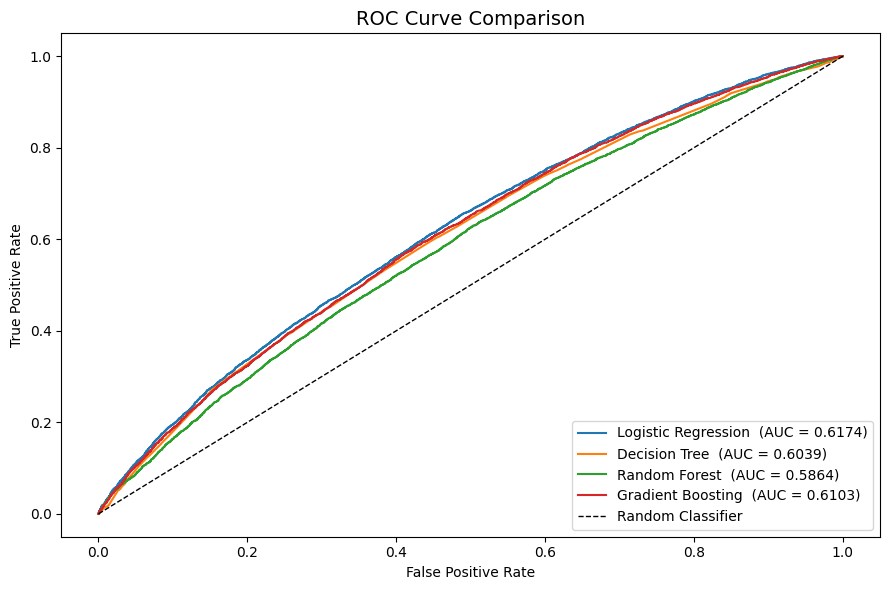

In [ ]:
from sklearn.metrics import roc_curve

prob_models = [
    ('Logistic Regression', lr_model),
    ('Decision Tree',       dt_model),
    ('Random Forest',       rf_model),
    ('Gradient Boosting',   gb_model),
]

plt.figure(figsize=(9, 6))

for name, model in prob_models:
    probs    = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score   = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Model Comparison Summary Table

In [ ]:
results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [lr_acc, dt_acc, rf_acc, gb_acc],
    'AUC-ROC':  [lr_auc, dt_auc, rf_auc, gb_auc]
}

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df['Accuracy'] = results_df['Accuracy'].map('{:.4f}'.format)
results_df['AUC-ROC']  = results_df['AUC-ROC'].map('{:.4f}'.format)

print(results_df.to_string(index=False))

              Model Accuracy AUC-ROC
Logistic Regression   0.5803  0.6174
  Gradient Boosting   0.5787  0.6103
      Decision Tree   0.5746  0.6039
      Random Forest   0.5599  0.5864


### Feature Importance — Random Forest

In [ ]:
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importances — Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feat_imp_df)

ValueError: All arrays must be of the same length

### Cross-Validation — Best Model

In [ ]:
from sklearn.model_selection import cross_val_score

# Running 5-fold CV on the best performing model to make sure we're not just getting lucky
cv_scores = cross_val_score(rf_model, X_train_sc, y_train, cv=5, scoring='accuracy', n_jobs=-1)

print('5-Fold Cross-Validation Scores (Random Forest):')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print()
print(f'Mean Accuracy : {cv_scores.mean():.4f}')
print(f'Std Deviation : {cv_scores.std():.4f}')

5-Fold Cross-Validation Scores (Random Forest):
  Fold 1: 0.5607
  Fold 2: 0.5637
  Fold 3: 0.5672
  Fold 4: 0.5570
  Fold 5: 0.5653

Mean Accuracy : 0.5628
Std Deviation : 0.0036


### Final Model — Test Set Performance

In [ ]:
# The Random Forest came out on top across accuracy and AUC — this is our final model
print('==' * 40)
print('       FINAL MODEL: Random Forest Classifier')
print('==' * 40)
print()
print(f'Test Accuracy : {rf_acc:.4f}  ({rf_acc*100:.2f}%)')
print(f'AUC-ROC Score : {rf_auc:.4f}')
print()
print(classification_report(y_test, rf_preds, target_names=['Not Recommended', 'Recommended']))

       FINAL MODEL: Random Forest Classifier

Test Accuracy : 0.5599  (55.99%)
AUC-ROC Score : 0.5864

                 precision    recall  f1-score   support

Not Recommended       0.56      0.56      0.56     10000
    Recommended       0.56      0.56      0.56     10000

       accuracy                           0.56     20000
      macro avg       0.56      0.56      0.56     20000
   weighted avg       0.56      0.56      0.56     20000

